In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert, find_peaks
from scipy import stats as spstats
import librosa
from IPython.display import Audio, display
from scipy.signal import welch

from scipy.io import wavfile
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, accuracy_score

In [13]:
def load_audio(file_path, target_fs=4000):
    x, _ = librosa.load(file_path, sr=target_fs, mono=True)
    t = np.arange(len(x)) / target_fs
    return x, target_fs, t

In [14]:
def bandpass_filter(x, fs, low=20, high=400, order=4):
    nyquist = fs / 2
    b, a = butter(order, [low/nyquist, high/nyquist], btype='band')
    return filtfilt(b, a, x)

def normalize(x):
    return x / (np.max(np.abs(x)) + 1e-12)

def preprocess(x, fs, low=20, high=400):
    x_filtrado = bandpass_filter(x, fs, low, high)
    return normalize(x_filtrado)

In [15]:
def plot_spectrum(x, fs, titulo=''):
    freqs, potencia = welch(x, fs=fs, nperseg=min(len(x), fs*2))
    plt.figure(figsize=(10, 3))
    plt.semilogy(freqs, potencia)
    plt.xlim(0, fs/2)
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Potencia (escala log)')
    plt.title(titulo)
    plt.grid(True)
    plt.show()
    return freqs, potencia

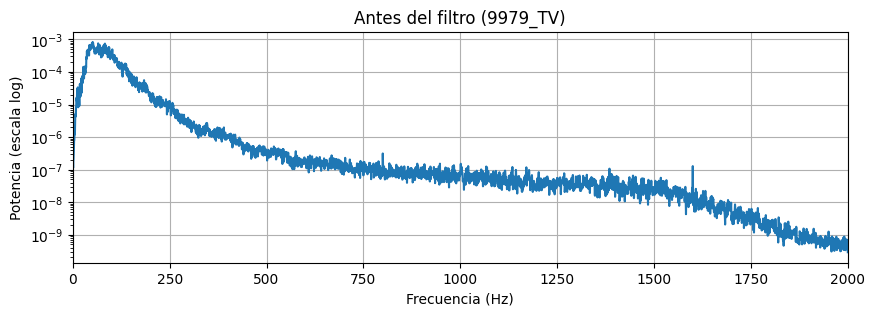

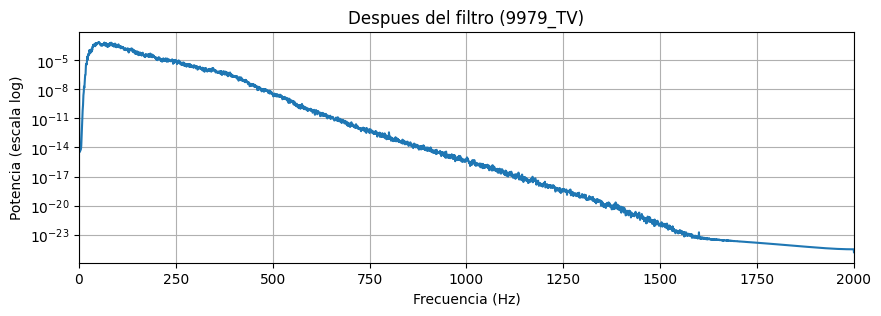

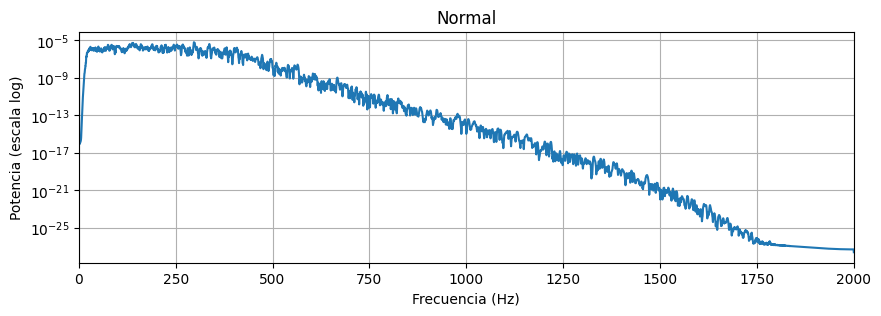

(array([0.0000e+00, 5.0000e-01, 1.0000e+00, ..., 1.9990e+03, 1.9995e+03,
        2.0000e+03]),
 array([8.21438531e-10, 4.10273914e-10, 8.00588299e-17, ...,
        5.22041248e-28, 5.22025433e-28, 2.61010600e-28]))

In [16]:
x_crudo, fs, t = load_audio(r"C:\Users\emigo\OneDrive\Documentos\Servicio Social\the-circor-digiscope-phonocardiogram-dataset-1.0.3\the-circor-digiscope-phonocardiogram-dataset-1.0.3\training_data\9979_TV.wav")
x_limpio = preprocess(x_crudo, fs)

x_crudo2, fs, t = load_audio(r"C:\Users\emigo\OneDrive\Documentos\Servicio Social\the-circor-digiscope-phonocardiogram-dataset-1.0.3\the-circor-digiscope-phonocardiogram-dataset-1.0.3\training_data\49568_AV.wav")
x_normal = preprocess(x_crudo2, fs)

plot_spectrum(x_crudo, fs, 'Antes del filtro (9979_TV)')
plot_spectrum(x_limpio, fs, 'Despues del filtro (9979_TV)')
plot_spectrum(x_normal, fs, 'Normal')

In [17]:
def graficar_tiempo(x, fs, titulo='', segundos=3):
    # Calcular cuántas muestras equivalen a los segundos deseados
    limite_muestras = int(segundos * fs)
    
    # Recortar la señal a esa cantidad de muestras
    x_recortado = x[:limite_muestras]
    
    # Crear el vector de tiempo solo para ese fragmento
    t = np.arange(len(x_recortado)) / fs
    
    plt.figure(figsize=(10, 3))
    plt.plot(t, x_recortado, linewidth=0.8)
    plt.xlim(0, t[-1])  # Se ajusta a los 3 segundos exactos
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.title(titulo)
    plt.grid(True)
    plt.show()

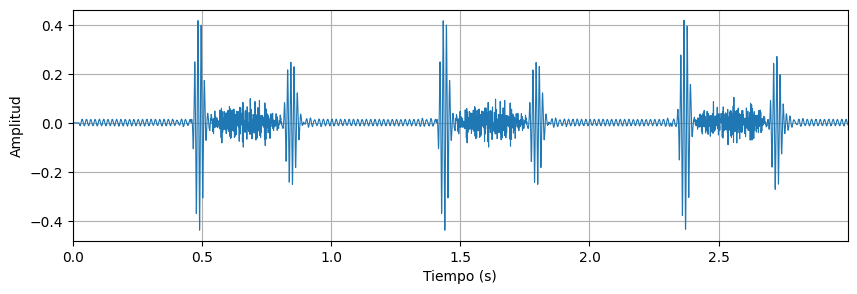

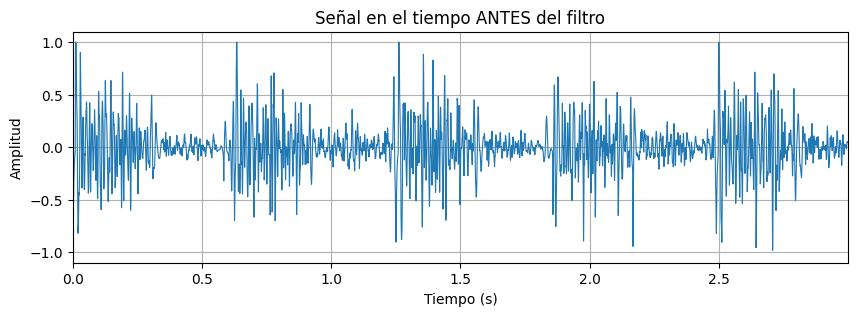

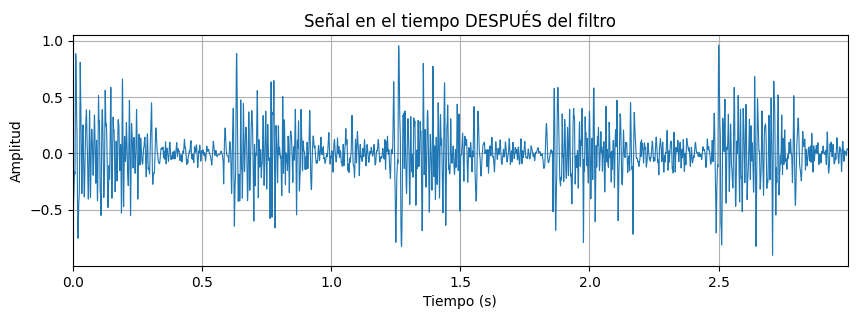

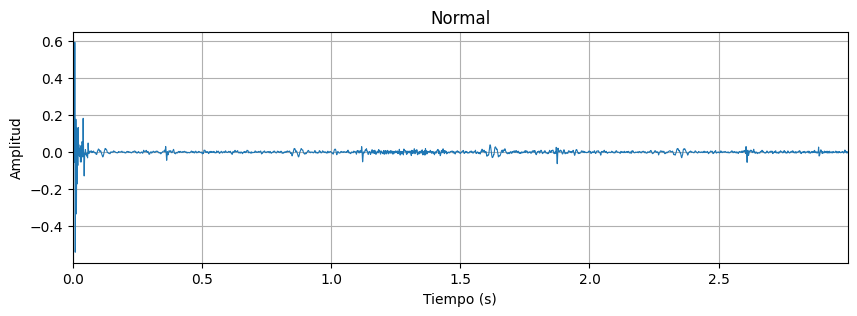

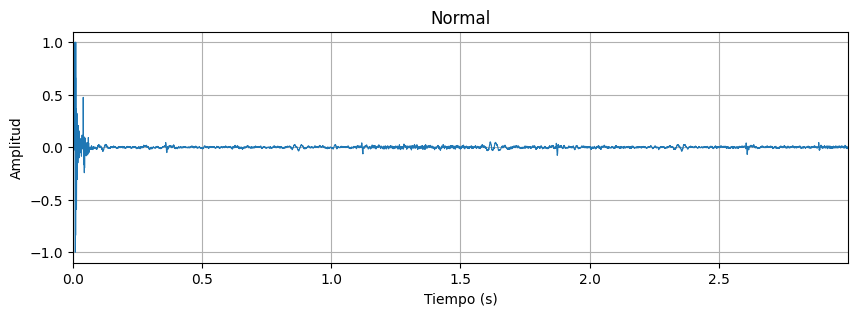

In [18]:
murmur_artificial, fs, t = load_audio(r"C:\Users\emigo\OneDrive\Documentos\Servicio Social\backend_carlos-20260331T010941Z-1-001\backend_carlos\backend_carlos\data\murmur_01.mp3")
graficar_tiempo(murmur_artificial,fs)

# Llamadas con los parámetros que ya tienes
graficar_tiempo(x_crudo, fs, 'Señal en el tiempo ANTES del filtro')
graficar_tiempo(x_limpio, fs, 'Señal en el tiempo DESPUÉS del filtro')
graficar_tiempo(x_normal, fs, 'Normal')
graficar_tiempo(x_crudo2, fs, 'Normal')

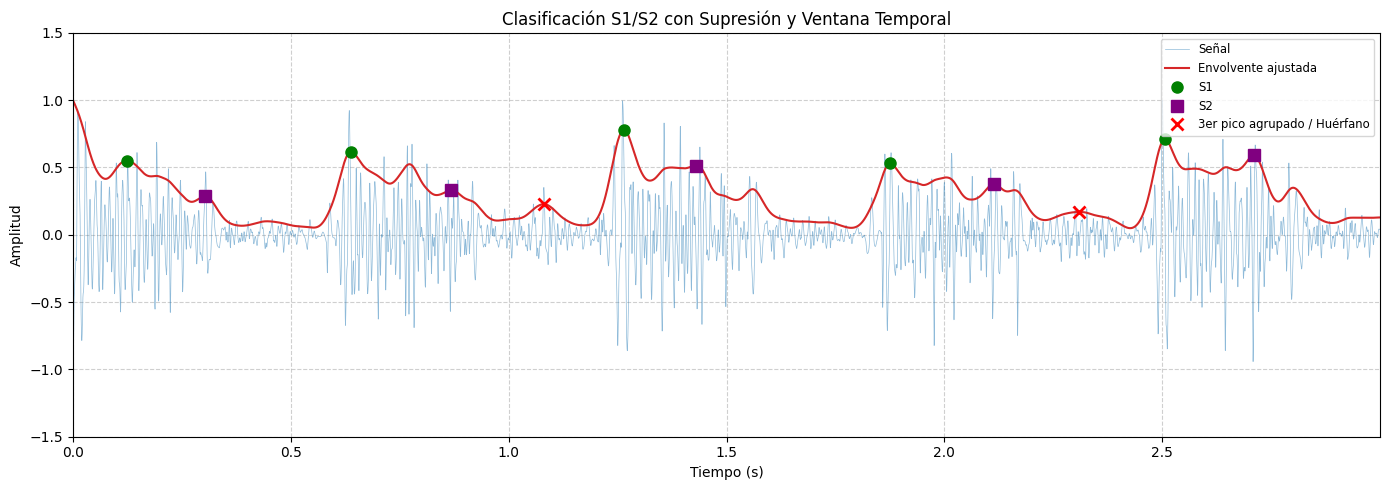

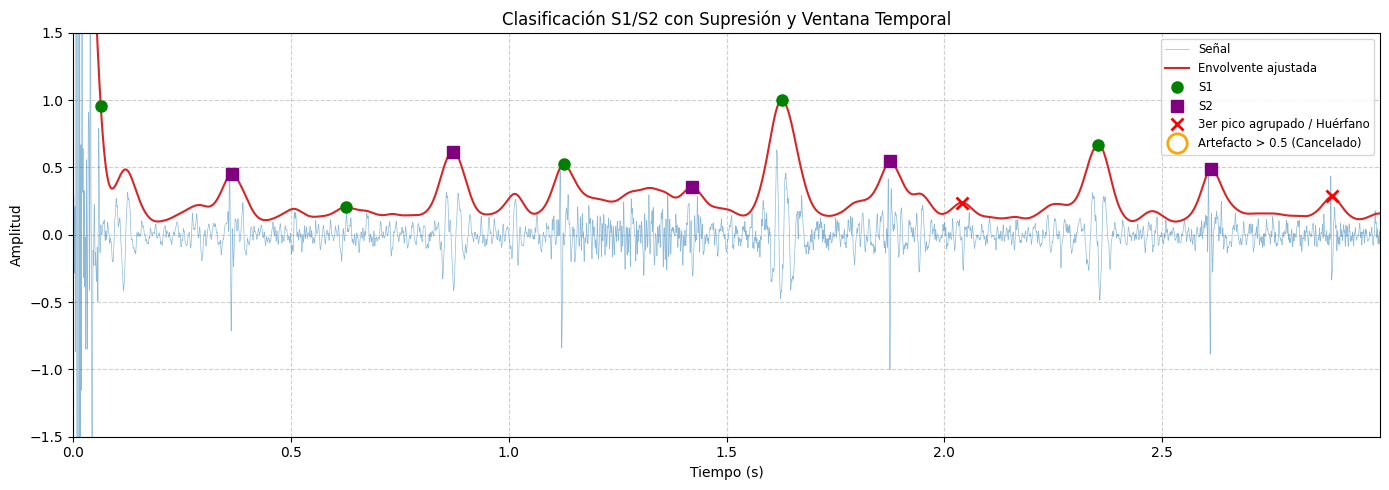

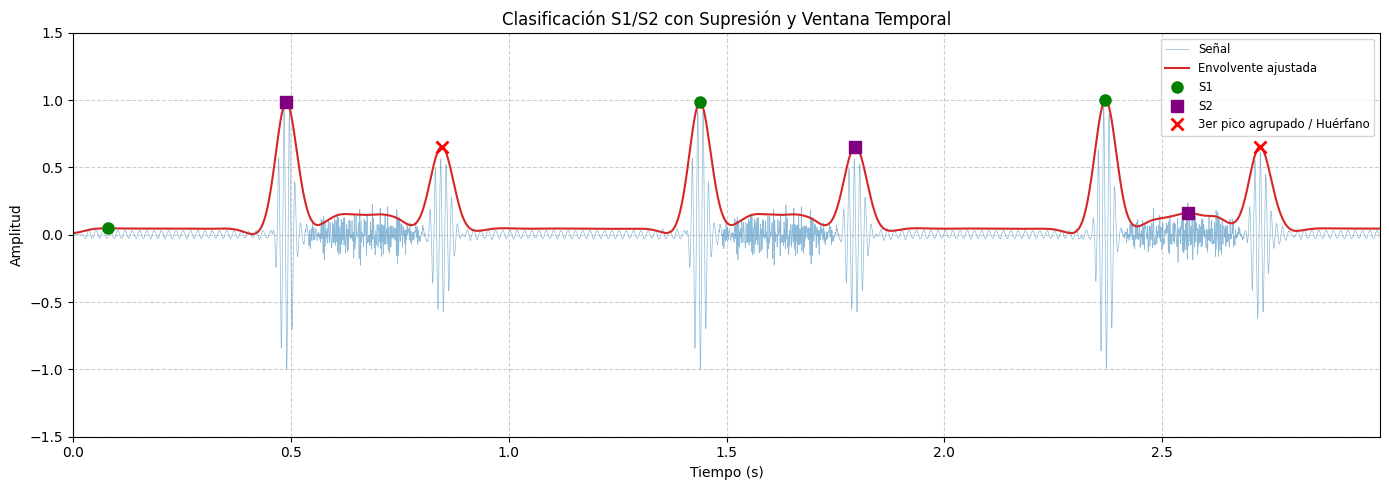

In [19]:
def obtener_envolvente_cruda(x, fs):
    """Calcula la envolvente sin normalizar."""
    senal_analitica = hilbert(x)
    envolvente = np.abs(senal_analitica)
    
    nyq = 0.5 * fs
    b, a = butter(2, 10 / nyq, btype='low')
    return filtfilt(b, a, envolvente)

def segmentar_y_clasificar_pcg(x, fs, t, segundos=3):
    limite = int(segundos * fs)
    x_rec = x[:limite]
    t_rec = t[:limite]
    
    env_cruda = obtener_envolvente_cruda(x_rec, fs)
    env_trabajo = env_cruda.copy() 
    
    distancia_minima = int(0.15 * fs)
    artefactos = []
    
    # 1. Bucle Iterativo: Cancelación si diferencia > 0.5
    while True:
        max_val = np.max(env_trabajo)
        if max_val == 0:
            break
            
        env_norm = env_trabajo / max_val
        picos_temp, _ = find_peaks(env_norm, distance=distancia_minima, prominence=0.03)
        
        if len(picos_temp) < 2:
            break
            
        # Ordenar picos por amplitud actual
        amplitudes = env_norm[picos_temp]
        indices_ordenados = np.argsort(amplitudes)[::-1]
        
        pico_max_idx = picos_temp[indices_ordenados[0]]
        pico_seg_idx = picos_temp[indices_ordenados[1]]
        
        amp_max = env_norm[pico_max_idx]
        amp_seg = env_norm[pico_seg_idx]
        
        # Condición: si es mayor a 0.5, cancelar el máximo y repetir
        if (amp_max - amp_seg) > 0.5:
            artefactos.append(pico_max_idx)
            # Enmascarar (cancelar) el pico anómalo para la siguiente iteración
            ventana = int(0.05 * fs) 
            inicio = max(0, pico_max_idx - ventana)
            fin = min(len(env_trabajo), pico_max_idx + ventana)
            env_trabajo[inicio:fin] = 0
        else:
            break

    # 2. Extraer picos válidos finales usando la escala del pico que hizo cumplir la condición
    max_real = np.max(env_trabajo) + 1e-12
    env_norm_final = env_trabajo / max_real
    picos_brutos, _ = find_peaks(env_norm_final, distance=distancia_minima, prominence=0.03)
    
    # 3. Lógica de clasificación S1, S2 y descarte de terceros picos
    s1_picos = []
    s2_picos = []
    picos_descartados = []
    
    ventana_min_sistole = int(0.15 * fs) # Distancia mínima esperada entre S1 y S2
    ventana_max_sistole = int(0.45 * fs) # Distancia máxima esperada entre S1 y S2
    
    i = 0
    while i < len(picos_brutos):
        pico_base = picos_brutos[i]
        
        # Buscar en la ventana hacia adelante
        candidatos = []
        for j in range(i + 1, len(picos_brutos)):
            distancia = picos_brutos[j] - pico_base
            if distancia <= ventana_max_sistole:
                candidatos.append(picos_brutos[j])
            else:
                break
                
        if len(candidatos) > 0:
            # Hay pareja. El primero es S1, el segundo es S2
            s1_picos.append(pico_base)
            s2_picos.append(candidatos[0])
            
            # Si llegaron más picos en esta misma ventana, son terceros/cuartos picos y se cancelan
            for extra in candidatos[1:]:
                picos_descartados.append(extra)
                
            # Avanzar el índice saltando la pareja y los descartados
            i += len(candidatos) + 1
        else:
            # Pico huérfano, no encontró S2 a tiempo (puede ser ruido al final o inicio de la señal)
            picos_descartados.append(pico_base)
            i += 1

    # --- Configuración Visual ---
    env_visual = env_cruda / max_real
    x_rec_visual = x_rec / (np.max(np.abs(x_rec[env_trabajo > 0])) + 1e-12) 

    plt.figure(figsize=(14, 5))
    plt.plot(t_rec, x_rec_visual, color='#1f77b4', linewidth=0.5, label='Señal', alpha=0.5)
    plt.plot(t_rec, env_visual, color='#d62728', linewidth=1.5, label='Envolvente ajustada')
    
    # Graficar S1 (Círculos verdes) y S2 (Cuadrados púrpuras)
    if s1_picos:
        plt.plot(t_rec[s1_picos], env_visual[s1_picos], "o", color='green', markersize=8, label='S1')
    if s2_picos:
        plt.plot(t_rec[s2_picos], env_visual[s2_picos], "s", color='purple', markersize=8, label='S2')
        
    # Graficar Terceros picos juntos ignorados (Cruces rojas)
    if picos_descartados:
        plt.plot(t_rec[picos_descartados], env_visual[picos_descartados], "x", color='red', markersize=8, markeredgewidth=2, label='3er pico agrupado / Huérfano')
        
    # Graficar los artefactos iniciales > 0.5 (Círculos naranjas grandes)
    if artefactos:
        plt.plot(t_rec[artefactos], env_visual[artefactos], "o", color='orange', markersize=14, fillstyle='none', markeredgewidth=2, label='Artefacto > 0.5 (Cancelado)')

    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.title('Clasificación S1/S2 con Supresión y Ventana Temporal')
    plt.ylim(-1.5, 1.5)
    plt.xlim(0, t_rec[-1])
    plt.legend(loc='upper right', fontsize='small')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return s1_picos, s2_picos, picos_descartados

# --- Uso ---
s1, s2, descartados = segmentar_y_clasificar_pcg(x_limpio, fs, t)

s1, s2, descartados = segmentar_y_clasificar_pcg(x_normal, fs, t)

s1, s2, descartados = segmentar_y_clasificar_pcg(murmur_artificial  , fs, t)

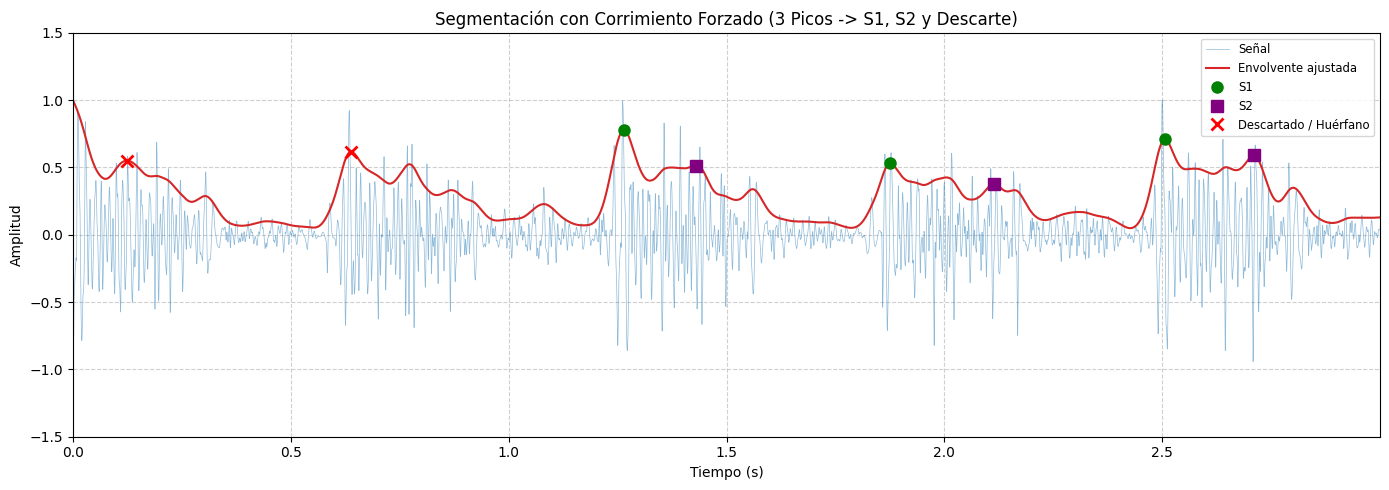

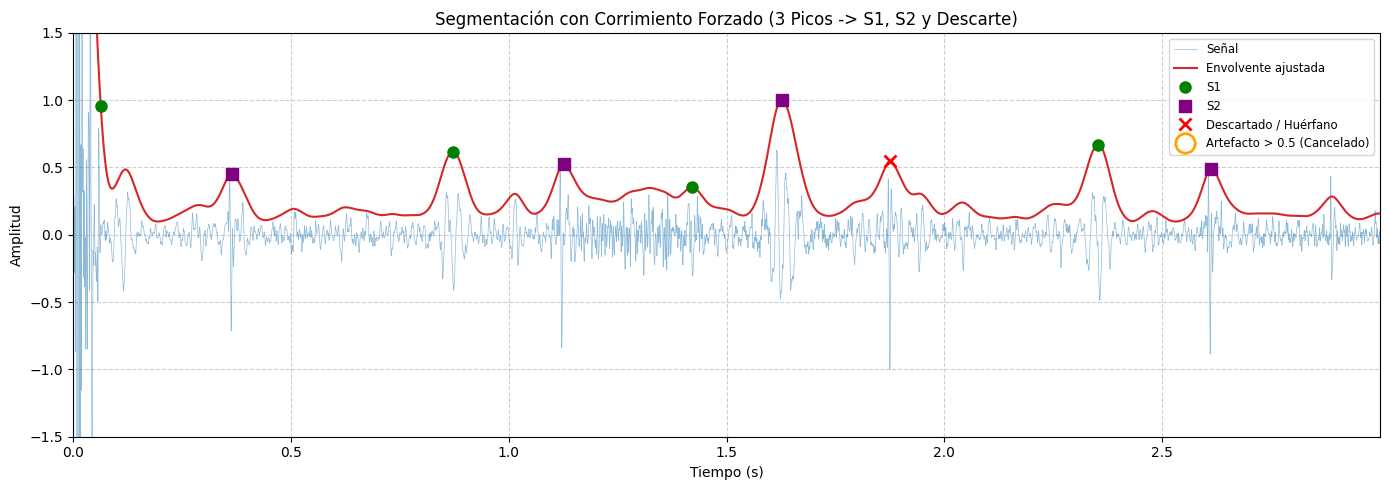

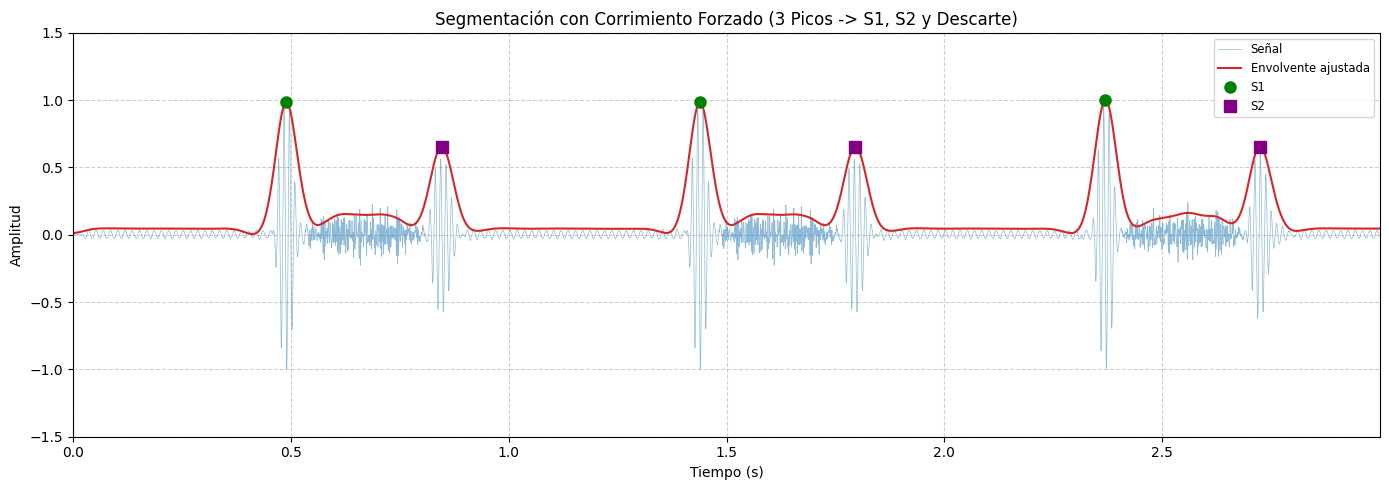

In [23]:
def obtener_envolvente_cruda2(x, fs):
    """Calcula la envolvente sin normalizar."""
    senal_analitica = hilbert(x)
    envolvente = np.abs(senal_analitica)
    
    nyq = 0.5 * fs
    b, a = butter(2, 10 / nyq, btype='low')
    return filtfilt(b, a, envolvente)

def segmentar_y_clasificar_pcg2(x, fs, t, segundos=3):
    limite = int(segundos * fs)
    x_rec = x[:limite]
    t_rec = t[:limite]
    
    env_cruda = obtener_envolvente_cruda2(x_rec, fs)
    env_trabajo = env_cruda.copy() 
    
    distancia_minima = int(0.15 * fs)
    artefactos = []
    
    # 1. Bucle Iterativo: Manejo exclusivo de la condición de diferencia > 0.5
    while True:
        max_val = np.max(env_trabajo)
        if max_val == 0:
            break
            
        env_norm = env_trabajo / max_val
        picos_temp, _ = find_peaks(env_norm, distance=distancia_minima, prominence=0.03)
        
        if len(picos_temp) < 2:
            break
            
        amplitudes = env_norm[picos_temp]
        indices_ordenados = np.argsort(amplitudes)[::-1]
        
        pico_max_idx = picos_temp[indices_ordenados[0]]
        pico_seg_idx = picos_temp[indices_ordenados[1]]
        
        amp_max = env_norm[pico_max_idx]
        amp_seg = env_norm[pico_seg_idx]
        
        if (amp_max - amp_seg) > 0.5:
            artefactos.append(pico_max_idx)
            ventana = int(0.05 * fs) 
            inicio = max(0, pico_max_idx - ventana)
            fin = min(len(env_trabajo), pico_max_idx + ventana)
            env_trabajo[inicio:fin] = 0
        else:
            break

    # 2. Detección Normal con tus parámetros estrictos
    max_real = np.max(env_trabajo) + 1e-12
    env_norm_final = env_trabajo / max_real
    picos_brutos, _ = find_peaks(env_norm_final, distance=distancia_minima, prominence=0.1, height=0.3)
    
    # 3. Lógica de clasificación S1, S2 y desplazamiento por tercer pico
    s1_picos = []
    s2_picos = []
    picos_descartados = []
    
    ventana_max_sistole = int(0.45 * fs) # Distancia máxima esperada entre S1 y S2
    
    i = 0
    while i < len(picos_brutos):
        pico_base = picos_brutos[i] # 1er pico
        
        candidatos = []
        for j in range(i + 1, len(picos_brutos)):
            distancia = picos_brutos[j] - pico_base
            if distancia <= ventana_max_sistole:
                candidatos.append(picos_brutos[j])
            else:
                break
                
        # Si encontramos al menos dos candidatos más (formando un grupo de 3 picos en total)
        if len(candidatos) >= 2:
            # REGLA DIRECTA DE CORRIMIENTO:
            picos_descartados.append(pico_base)       # El 1er pico (verde) pasa a ser descartado/huérfano
            s1_picos.append(candidatos[0])             # El 2do pico (morado) se convierte en S1
            s2_picos.append(candidatos[1])             # El 3ro pico (rojo huérfano) se convierte en S2
            
            # Si hay más picos en la ventana, se descartan
            for extra in candidatos[2:]:
                picos_descartados.append(extra)
                
            i += 3 # Saltamos los 3 picos procesados
            
        elif len(candidatos) == 1:
            # Comportamiento normal: pareja estándar S1 y S2
            s1_picos.append(pico_base)
            s2_picos.append(candidatos[0])
            i += 2
        else:
            # Pico huérfano sin pareja
            picos_descartados.append(pico_base)
            i += 1

    # --- Configuración Visual ---
    env_visual = env_cruda / max_real
    x_rec_visual = x_rec / (np.max(np.abs(x_rec[env_trabajo > 0])) + 1e-12) 

    plt.figure(figsize=(14, 5))
    plt.plot(t_rec, x_rec_visual, color='#1f77b4', linewidth=0.5, label='Señal', alpha=0.5)
    plt.plot(t_rec, env_visual, color='#d62728', linewidth=1.5, label='Envolvente ajustada')
    
    if s1_picos:
        plt.plot(t_rec[s1_picos], env_visual[s1_picos], "o", color='green', markersize=8, label='S1')
    if s2_picos:
        plt.plot(t_rec[s2_picos], env_visual[s2_picos], "s", color='purple', markersize=8, label='S2')
        
    if picos_descartados:
        plt.plot(t_rec[picos_descartados], env_visual[picos_descartados], "x", color='red', markersize=8, markeredgewidth=2, label='Descartado / Huérfano')
        
    if artefactos:
        plt.plot(t_rec[artefactos], env_visual[artefactos], "o", color='orange', markersize=14, fillstyle='none', markeredgewidth=2, label='Artefacto > 0.5 (Cancelado)')

    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.title('Segmentación con Corrimiento Forzado (3 Picos -> S1, S2 y Descarte)')
    plt.ylim(-1.5, 1.5)
    plt.xlim(0, t_rec[-1])
    plt.legend(loc='upper right', fontsize='small')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return s1_picos, s2_picos, picos_descartados
        
s1, s2, descartados = segmentar_y_clasificar_pcg2(x_limpio, fs, t)

s1, s2, descartados = segmentar_y_clasificar_pcg2(x_normal, fs, t)

s1, s2, descartados = segmentar_y_clasificar_pcg2(murmur_artificial  , fs, t)